# ALMA peak signal-to-noise contours on rotated JWST zooms

This notebook finds every local `*_maximum.fits` map with a matching `*_rms.fits` map in `data/`. It plots maximum/RMS contours on NIRCam (left) and MIRI (right) RGB images, retaining the rotation used by `plot_miri_rgb_rotated_wcs.ipynb`.

In [1]:
from pathlib import Path
import re

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from matplotlib.colors import Normalize
from matplotlib.image import imread
from PIL import Image
from scipy.ndimage import binary_propagation, map_coordinates

Image.MAX_IMAGE_PIXELS = None

REPO_DIR = Path('/Users/abarnes/Library/CloudStorage/Dropbox/GitHub/cloudh_outflows')
ALMA_DIR = REPO_DIR / 'data'
JWST_DIR = Path('/Users/abarnes/Library/CloudStorage/Dropbox/Data/Galactic/JWST/cloud_h/jwst/fits/nanfilled/reprojected')
PLOT_DIR = REPO_DIR / 'plots'

MIRI_JPEG = JWST_DIR / 'miri_photoshop.jpeg'
MIRI_WCS_FITS = JWST_DIR / 'jw07230-o002_t003_miri_f770w_i2d_nanfilled_reprojected.fits'
NIRCAM_JPEG = JWST_DIR / 'nircam_photoshop.jpeg'
NIRCAM_WCS_FITS = JWST_DIR / 'jw07230-o004_t003_nircam_clear-f356w_i2d_nanfilled_reprojected.fits'

MAXIMUM_MAPS = sorted(ALMA_DIR.glob('*_maximum.fits'))
if not MAXIMUM_MAPS:
    raise FileNotFoundError(f'No *_maximum.fits maps found in {ALMA_DIR}.')

DISPLAY_PA_DEG = 354.80557109226515 - 360
FOOTPRINT_PADDING_PIXELS = 12
MIRI_WHITE_THRESHOLD = 245
SNR_LEVELS = np.array([3, 5, 10, 20, 40, 80], dtype=float)
SNR_NORM = Normalize(vmin=SNR_LEVELS.min(), vmax=SNR_LEVELS.max())

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'


In [2]:
# Read the RGB JPEGs and their matching celestial WCS files.
# JPEG row 0 is at the top, unlike FITS/WCS y=0.
miri_rgb = np.flipud(imread(MIRI_JPEG)[..., :3]).copy()
nircam_rgb = np.flipud(imread(NIRCAM_JPEG)[..., :3])

with fits.open(MIRI_WCS_FITS, memmap=True) as hdul:
    miri_shape = hdul[1].data.shape
    miri_wcs = WCS(hdul[1].header).celestial
with fits.open(NIRCAM_WCS_FITS, memmap=True) as hdul:
    nircam_shape = hdul[1].data.shape
    nircam_wcs = WCS(hdul[1].header).celestial

if miri_rgb.shape[:2] != miri_shape:
    raise ValueError(f'MIRI JPEG shape {miri_rgb.shape[:2]} does not match FITS shape {miri_shape}.')
if nircam_rgb.shape[:2] != nircam_shape:
    raise ValueError(f'NIRCam JPEG shape {nircam_rgb.shape[:2]} does not match FITS shape {nircam_shape}.')

miri_white = np.all(miri_rgb >= MIRI_WHITE_THRESHOLD, axis=2)
miri_edge = np.zeros(miri_shape, dtype=bool)
miri_edge[[0, -1], :] = True
miri_edge[:, [0, -1]] = True
miri_rgb[binary_propagation(miri_edge & miri_white, mask=miri_white)] = 0
miri_pixel_scale = (np.mean(proj_plane_pixel_scales(miri_wcs)) * u.deg).to_value(u.arcsec)
print(f'MIRI display pixel scale: {miri_pixel_scale:.4f} arcsec/pixel')


MIRI display pixel scale: 0.1109 arcsec/pixel


Set DATE-AVG to '2026-04-20T19:13:48.581' from MJD-AVG.
Set DATE-END to '2026-04-20T20:21:51.119' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -19.247298 from OBSGEO-[XYZ].
Set OBSGEO-H to 1505726645.939 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2026-05-12T02:20:38.473' from MJD-AVG.
Set DATE-END to '2026-05-12T02:31:06.605' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -29.337902 from OBSGEO-[XYZ].
Set OBSGEO-H to 1674445997.841 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [3]:
def read_peak_snr(maximum_path):
    rms_path = maximum_path.with_name(maximum_path.name.replace('_maximum.fits', '_rms.fits'))
    if not rms_path.exists():
        raise FileNotFoundError(f'Missing RMS map for {maximum_path.name}: {rms_path.name}')
    with fits.open(maximum_path, memmap=True) as hdul:
        maximum = np.squeeze(hdul[0].data).astype(float)
        header = hdul[0].header.copy()
    with fits.open(rms_path, memmap=True) as hdul:
        rms = np.squeeze(hdul[0].data).astype(float)
    if maximum.ndim != 2 or rms.shape != maximum.shape:
        raise ValueError(f'Incompatible maximum/RMS shapes for {maximum_path.name}.')
    coverage = np.isfinite(rms) & (rms > 0)
    if not coverage.any():
        raise ValueError(f'{rms_path.name} has no finite positive RMS coverage.')
    snr = np.full(maximum.shape, np.nan)
    valid_snr = coverage & np.isfinite(maximum)
    snr[valid_snr] = maximum[valid_snr] / rms[valid_snr]
    return snr, WCS(header).celestial, coverage


def make_rotated_wcs(alma_wcs, coverage):
    y, x = np.nonzero(coverage)
    center = alma_wcs.pixel_to_world((x.min() + x.max()) / 2, (y.min() + y.max()) / 2)
    rotation = np.deg2rad(DISPLAY_PA_DEG + 90)
    display_wcs = WCS(naxis=2)
    display_wcs.wcs.ctype = ['RA---TAN', 'DEC--TAN']
    display_wcs.wcs.cunit = ['deg', 'deg']
    display_wcs.wcs.crval = [center.ra.deg, center.dec.deg]
    display_wcs.wcs.crpix = [1, 1]
    display_wcs.wcs.cdelt = [miri_pixel_scale / 3600, miri_pixel_scale / 3600]
    display_wcs.wcs.pc = np.array([[-1, 0], [0, 1]]) @ np.array([
        [np.cos(rotation), -np.sin(rotation)],
        [np.sin(rotation), np.cos(rotation)],
    ])
    display_wcs.wcs.set()
    x_out, y_out = display_wcs.world_to_pixel(alma_wcs.pixel_to_world(x, y))
    xmin, xmax = x_out.min(), x_out.max()
    ymin, ymax = y_out.min(), y_out.max()
    width = int(np.ceil(xmax - xmin + 1 + 2 * FOOTPRINT_PADDING_PIXELS))
    height = int(np.ceil(ymax - ymin + 1 + 2 * FOOTPRINT_PADDING_PIXELS))
    display_wcs.wcs.crpix = [1 - xmin + FOOTPRINT_PADDING_PIXELS, 1 - ymin + FOOTPRINT_PADDING_PIXELS]
    display_wcs.wcs.set()
    return display_wcs, width, height


def sample_rgb(rgb, input_wcs, ra, dec):
    x, y = input_wcs.world_to_pixel_values(ra, dec)
    sampled = np.empty(ra.shape + (3,), dtype=rgb.dtype)
    for channel in range(3):
        sampled[..., channel] = map_coordinates(rgb[..., channel], [y, x], order=1, mode='constant', cval=0)
    return sampled


def sample_map(data, coverage, input_wcs, ra, dec):
    x, y = input_wcs.world_to_pixel_values(ra, dec)
    sampled_data = map_coordinates(data, [y, x], order=1, mode='constant', cval=np.nan)
    sampled_coverage = map_coordinates(coverage.astype(float), [y, x], order=0, mode='constant', cval=0)
    return sampled_data, sampled_coverage


def label_and_stem(maximum_path):
    source = 'Clump H6' if 'Clump_H6' in maximum_path.name else 'AGAL 035.607-00.244'
    spw = re.search(r'\.spw(\d+)\.', maximum_path.name).group(1)
    return f'{source}, spw{spw}', f"{source.lower().replace(' ', '_').replace('-', '_')}_spw{spw}"


Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.


Saved /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/cloudh_outflows/plots/alma_snr_contours_nircam_miri_clump_h6_spw31.pdf
Saved /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/cloudh_outflows/plots/alma_snr_contours_nircam_miri_clump_h6_spw31.png


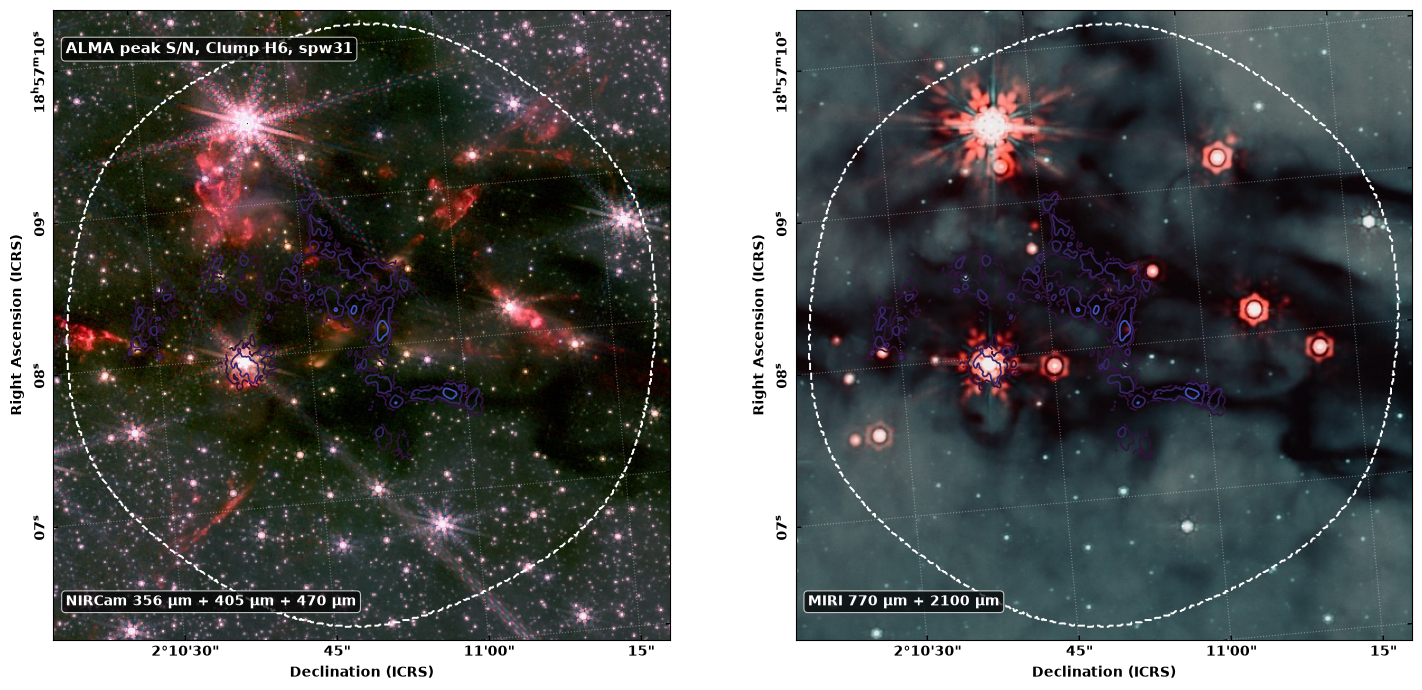

Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


Saved /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/cloudh_outflows/plots/alma_snr_contours_nircam_miri_clump_h6_spw33.pdf
Saved /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/cloudh_outflows/plots/alma_snr_contours_nircam_miri_clump_h6_spw33.png


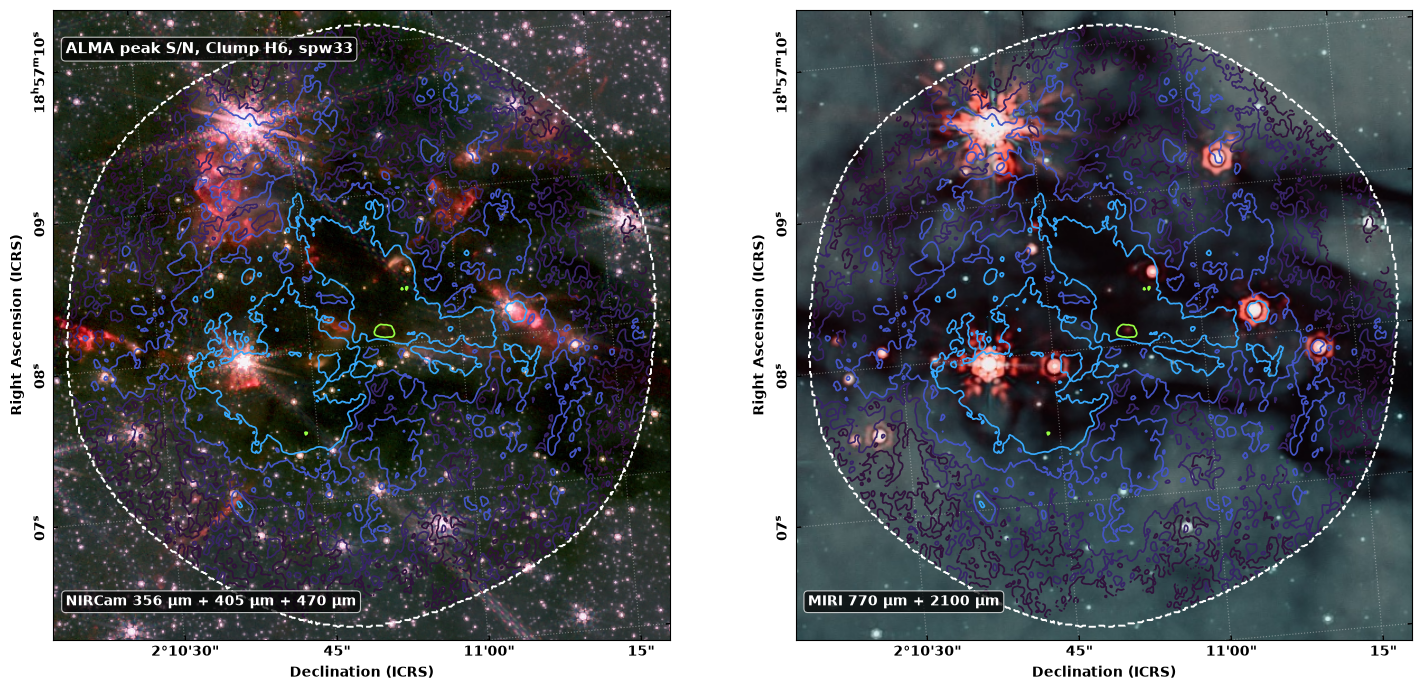

Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


Saved /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/cloudh_outflows/plots/alma_snr_contours_nircam_miri_clump_h6_spw43.pdf
Saved /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/cloudh_outflows/plots/alma_snr_contours_nircam_miri_clump_h6_spw43.png


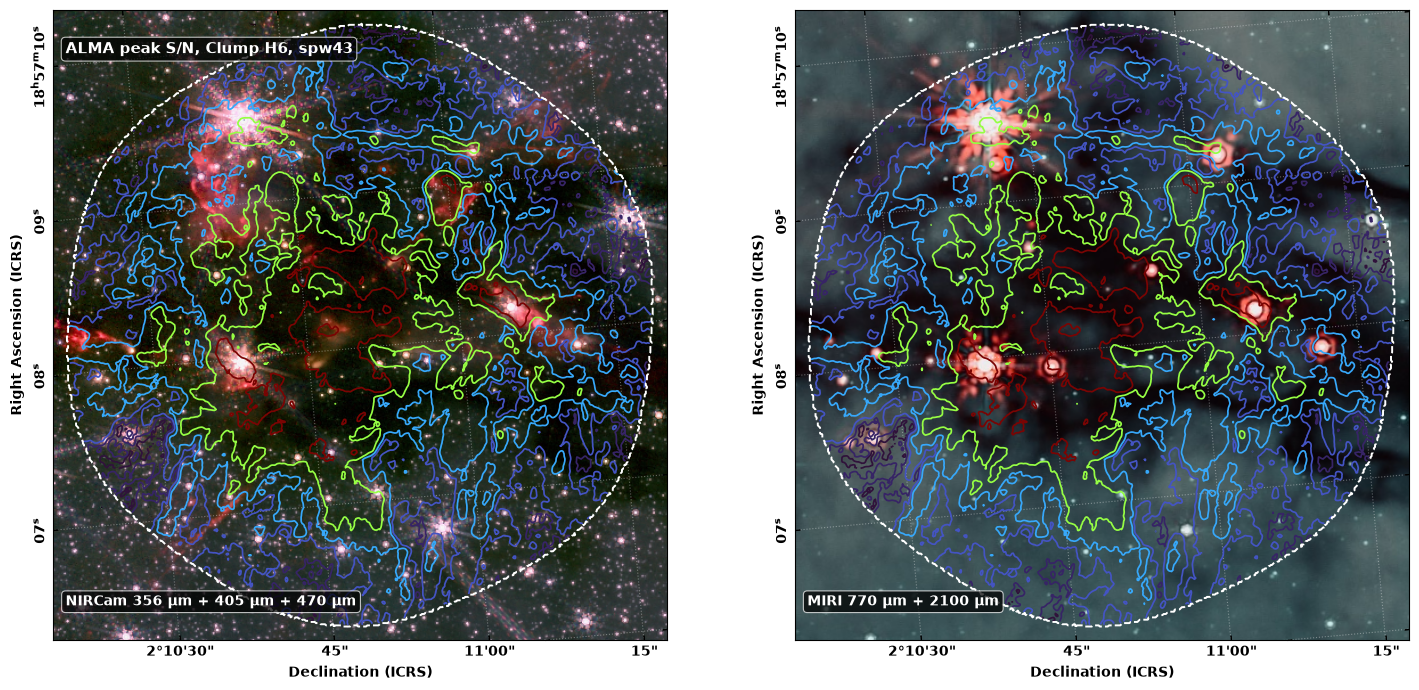

In [4]:
for maximum_path in MAXIMUM_MAPS:
    label, output_stem = label_and_stem(maximum_path)
    snr, alma_wcs, coverage = read_peak_snr(maximum_path)
    display_wcs, display_width, display_height = make_rotated_wcs(alma_wcs, coverage)

    display_y, display_x = np.mgrid[0:display_height, 0:display_width]
    ra, dec = display_wcs.pixel_to_world_values(display_x, display_y)
    display_nircam = sample_rgb(nircam_rgb, nircam_wcs, ra, dec)
    display_miri = sample_rgb(miri_rgb, miri_wcs, ra, dec)
    display_snr, display_coverage = sample_map(snr, coverage, alma_wcs, ra, dec)

    map_maximum = np.nanmax(display_snr[display_coverage > 0.5])
    levels = SNR_LEVELS[SNR_LEVELS <= map_maximum]
    if len(levels) < 2:
        raise ValueError(f'{maximum_path.name} does not reach two requested S/N contour levels.')

    fig = plt.figure(figsize=(15, 7))
    axes = [fig.add_subplot(1, 2, i, projection=display_wcs) for i in (1, 2)]
    for ax, image, title in zip(
        axes,
        (display_nircam, display_miri),
        ('NIRCam 356 μm + 405 μm + 470 μm', 'MIRI 770 μm + 2100 μm'),
    ):
        ax.set_facecolor('black')
        ax.imshow(image, origin='lower')
        ax.contour(display_snr, levels=levels, cmap='turbo', norm=SNR_NORM, linewidths=1.25)
        ax.contour(display_coverage, levels=[0.5], colors='white', linestyles='--', linewidths=1.4)
        ax.coords.grid(color='white', alpha=0.35, linestyle=':')
        ax.coords[0].set_axislabel('Right Ascension (ICRS)')
        ax.coords[1].set_axislabel('Declination (ICRS)')
        ax.coords[0].set_major_formatter('hh:mm:ss')
        ax.coords[1].set_major_formatter('dd:mm:ss')
        ax.coords[0].set_ticklabel(rotation=90, ha='left', va='center')
        ax.text(0.02, 0.05, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=10, fontweight='bold', color='white',
                bbox=dict(boxstyle='round,pad=0.28', facecolor='black', edgecolor='white', linewidth=0.8, alpha=0.72))

    axes[0].text(0.02, 0.95, f'ALMA peak S/N, {label}', transform=axes[0].transAxes, ha='left', va='top', fontsize=11, fontweight='bold', color='white',
                 bbox=dict(boxstyle='round,pad=0.28', facecolor='black', edgecolor='white', linewidth=0.8, alpha=0.72))
    fig.tight_layout()

    for extension in ('pdf', 'png'):
        output_path = PLOT_DIR / f'alma_snr_contours_nircam_miri_{output_stem}.{extension}'
        fig.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f'Saved {output_path}')
    plt.show()
